(ch:priors)=
# 5. Priors

```{admonition} Goals of this chapter
:class: note
After working through this chapter you should be able to

* explain what a prior is, distinguish informative, weakly informative, flat, improper and conjugate priors, and choose a sensible one for a given problem;
* derive the posterior analytically for the two conjugate pairs used in this course, Gaussian–Gaussian and Poisson–Gamma, and interpret the result ("the prior acts like extra data");
* explain the *shrinkage* of noisy estimates towards the prior mean, using the kidney-cancer example of the lecture;
* use physical constraints and results from other experiments as priors, and know when the prior matters and when it does not.

This chapter accompanies the second part of Lecture 4. The pen-and-paper exercises of the werkcollege (the Poisson model for kidney cancer death rates) build directly on Section 5.5.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(5)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

## 5.1 What is a prior?

The prior $p(\theta)$ is the first of the three steps of Bayesian inference (Chapter {ref}`4 <ch:inference>`): a probability distribution that encodes what we know, or are willing to assume, about the parameters *before* looking at the data. Bayes' theorem then tells us how the data update this knowledge into the posterior. The information in a prior can come from previous experiments, from physics, or from plain logic (a mass is positive, a probability lies between 0 and 1, the age of the Universe is larger than the age of the oldest stars). Different people may reasonably choose different priors for the same experiment; the choice must be made *without looking at the data* that will be analysed, and it should be stated in your report.

Frequentists do not use priors. They can still use previous results (to fix a parameter, to formulate a null hypothesis, to decide what data to collect), but they cannot combine a full previous probability distribution with new data. In the Bayesian framework this is automatic: yesterday's posterior is today's prior (Eq. {eq}`eq:updating`). As Hogg et al. put it: it is unfortunate that priors must be specified, but a prior is a *necessary condition* for marginalization, and marginalization is necessary whenever there are nuisance parameters, which is almost always.

## 5.2 Strong and weak priors

A **strong** (narrow, informative) prior expresses a high level of certainty about the parameter before seeing the data and will pull the posterior towards its centre; a **weak** (broad) prior expresses little certainty and lets the data speak. The prior need not be Gaussian and need not even be normalizable (see improper priors below).

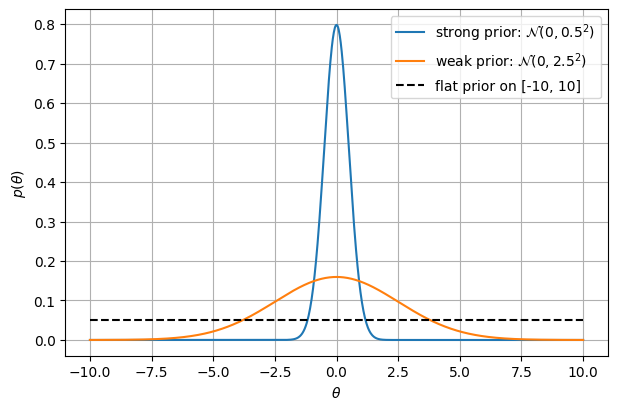

In [2]:
theta = np.linspace(-10, 10, 1000)
fig, ax = plt.subplots()
ax.plot(theta, stats.norm.pdf(theta, 0, 0.5), label=r"strong prior: $\mathcal{N}(0, 0.5^2)$")
ax.plot(theta, stats.norm.pdf(theta, 0, 2.5), label=r"weak prior: $\mathcal{N}(0, 2.5^2)$")
ax.plot(theta, np.full_like(theta, 0.05), "k--", label="flat prior on [-10, 10]")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$p(\theta)$"); ax.legend();

## 5.3 Types of priors

**Informative prior.** Conveys substantial information about the parameter, typically the posterior of a previous analysis (Section 5.6), or a well-established physical constraint. Use it when you have it; it improves the inference, and with enough new data the posterior will be dominated by the data anyway.

**Weakly informative prior.** Rough, deliberately conservative information: e.g. "the slope is somewhere between $-100$ and $100$", or a broad Gaussian around a plausible value. Gelman et al. give two recipes: start from a non-informative prior and add just enough information to keep the inference reasonable (exclude absurd values, help the sampler); or start from a strong prior and broaden it to account for the uncertainty in one's prior beliefs.

**Non-informative (flat, uniform) prior.** $p(\theta) = $ const over some range. This is the default in this course and in most of astronomy: the posterior is then proportional to the likelihood, and the credible intervals often coincide with frequentist confidence intervals. Two caveats:

* "Flat" depends on the parametrization. A prior that is flat in $\theta$ is not flat in $\ln\theta$ or $1/\theta$. For a *scale* parameter (a variance, a timescale, a luminosity) that can range over orders of magnitude, a prior flat in $\ln\theta$ (i.e. $p(\theta)\propto 1/\theta$) is usually the better "non-informative" choice, because it does not favour large values. Hogg et al. use it for the variance of the outlier distribution in Chapter {ref}`7 <ch:advanced>`.
* A flat prior over an infinite range does not integrate to one. It is an **improper prior**. That is usually harmless: as long as the likelihood falls off fast enough the *posterior* is a proper, normalizable distribution. (It is a problem for computing the evidence $p(y)$, which we do not need for parameter inference.)

**Diffuse prior.** A proper but very broad distribution, e.g. a Gaussian with a huge standard deviation; in practice it behaves like a flat prior.

**Conjugate prior.** A prior chosen such that the posterior belongs to the same family of distributions as the prior. Then Bayes' theorem can be evaluated with pen and paper, and the "updating" by the data reduces to updating the parameters of the family (called *hyperparameters*). The two cases that matter for this course, Gaussian–Gaussian and Poisson–Gamma, are worked out below; a third, Beta–Binomial, is the coin-flip example. Conjugate priors are convenient rather than principled: use them when their shape is reasonable for your problem, not merely because the algebra is nice.

(sec:hyperparameters)=
```{admonition} Hyperparameters
:class: important
The parameters of a prior distribution are called **hyperparameters**, to distinguish them from the parameters $\theta$ of the physical model. The prior $\mu \sim \mathcal{N}(\mu_0, \tau_0^2)$ for a mean $\mu$ has hyperparameters $\mu_0$ (where we think $\mu$ is) and $\tau_0$ (how sure we are); the Gamma prior for a rate has $\alpha$ and $\beta$; the Beta prior for a probability has $a$ and $b$. In these notes we write hyperparameters with a subscript $0$ or with Greek letters that do not appear in the model, and we reserve $\theta$ for the model parameters.

Hyperparameters can be treated in three ways:

1. **fixed by hand**, from physics or from previous experiments (Sections 5.4–5.6);
2. **estimated from the data themselves**, as in the kidney-cancer example where $\alpha$ and $\beta$ are matched to the spread of all counties (*empirical Bayes*);
3. **inferred together with $\theta$**, by giving them a prior of their own (a *hyperprior*) and marginalizing over them. This is a *hierarchical model*; it is beyond this course, except for one example: the outlier model of Chapter {ref}`7 <ch:advanced>`, in which the fraction and the distribution of the bad points are described by hyperparameters that are sampled along with the line and then marginalized away.
```

## 5.4 Example: the bias of a coin (Beta–Binomial)

We want to know the probability $\theta$ that a coin lands heads. Before we start, friends have flipped the same coin and found 9 heads and 11 tails; that is our prior information. We then flip the coin ourselves, $N$ times, and count $h$ heads.

*Model:* the number of heads in $N$ flips is binomial, $p(h\,|\,\theta, N) = \binom{N}{h}\theta^h(1-\theta)^{N-h}$.

*Prior:* the conjugate prior of the binomial is the **Beta distribution**, $p(\theta) \propto \theta^{a-1}(1-\theta)^{b-1}$ on $[0,1]$, with mean $a/(a+b)$. A flat prior is $\mathrm{Beta}(1,1)$, and after $h$ heads and $N-h$ tails it becomes $\mathrm{Beta}(1+h, 1+N-h)$; this is the sense in which "the prior is previous data". Our friends' 9 heads and 11 tails therefore give us the prior $\mathrm{Beta}(10, 12)$.

*Posterior:* multiply,

$$
p(\theta\,|\,h) \propto \theta^h(1-\theta)^{N-h}\,\theta^{a-1}(1-\theta)^{b-1} = \theta^{(a+h)-1}(1-\theta)^{(b+N-h)-1} ,
$$

which is again a Beta distribution, with $a \to a + h$ and $b \to b + (N-h)$. The hyperparameters simply count heads and tails.

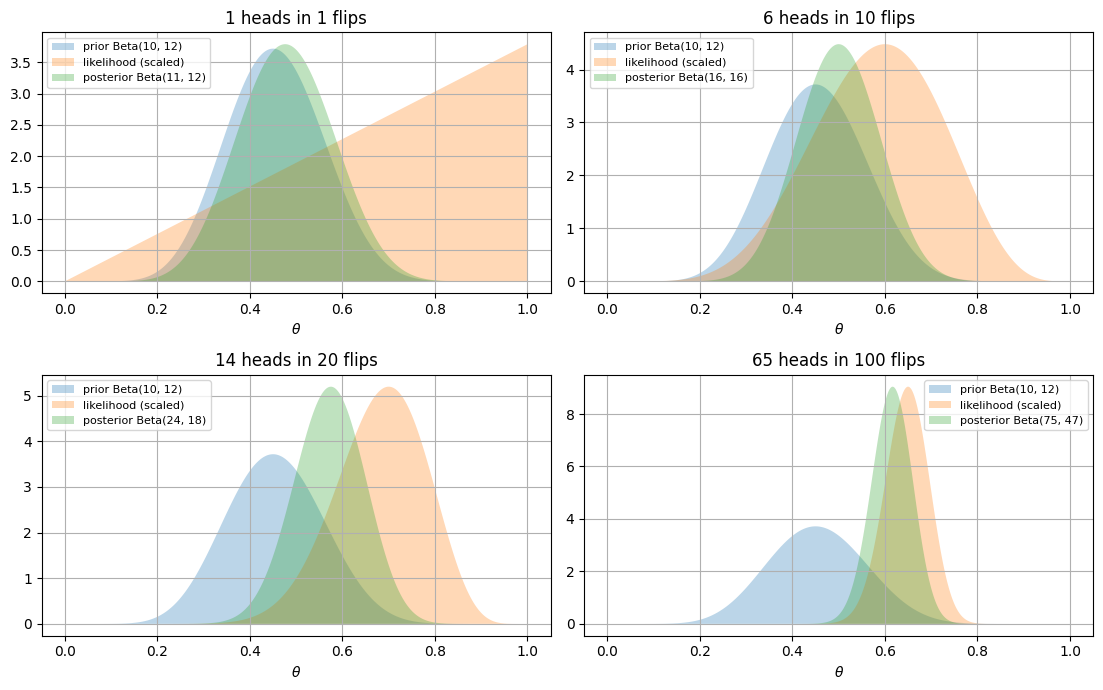

In [3]:
a0, b0 = 10, 12                                  # prior: flat prior updated with the 9 heads and 11 tails seen by our friends
outcomes = [(1, 1), (6, 10), (14, 20), (65, 100)] # (heads, flips) after 1, 10, 20 and 100 of our own flips
theta = np.linspace(0, 1, 500)

fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for ax, (h, N) in zip(axs.flat, outcomes):
    prior = stats.beta.pdf(theta, a0, b0)
    like = stats.binom.pmf(h, N, theta)
    post = stats.beta.pdf(theta, a0 + h, b0 + N - h)
    ax.fill_between(theta, prior, alpha=0.3, label=f"prior Beta({a0}, {b0})")
    ax.fill_between(theta, like / like.max() * post.max(), alpha=0.3, label="likelihood (scaled)")
    ax.fill_between(theta, post, alpha=0.3, label=f"posterior Beta({a0+h}, {b0+N-h})")
    ax.set_title(f"{h} heads in {N} flips"); ax.set_xlabel(r"$\theta$"); ax.legend(fontsize=8)
plt.tight_layout()

After one flip the posterior is essentially the prior; after 100 flips the data (65% heads) have overruled the prior belief of a fair coin. This is the general behaviour: the prior matters when the data are few, and becomes irrelevant when the data are many.

## 5.5 Two conjugate pairs you should know

### Gaussian likelihood, Gaussian prior

Take a single measurement $y$ of a quantity $\mu$ with known Gaussian uncertainty $\sigma$: $y \sim \mathcal{N}(\mu, \sigma^2)$. As prior for $\mu$ we take a Gaussian with hyperparameters $\mu_0$ (prior mean) and $\tau_0$ (prior width): $\mu \sim \mathcal{N}(\mu_0, \tau_0^2)$. The posterior is

$$
p(\mu\,|\,y) \propto \exp\left[-\frac{(y-\mu)^2}{2\sigma^2}\right]\exp\left[-\frac{(\mu-\mu_0)^2}{2\tau_0^2}\right] .
$$

The exponent is a quadratic function of $\mu$, so the posterior is again Gaussian, $\mu\,|\,y \sim \mathcal{N}(\mu_1, \tau_1^2)$.

```{admonition} Derivation (from the board in Lecture 4)
:class: note
Collect the exponent and expand the squares, dropping every term that does not contain $\mu$ (they only change the normalization):

$$
-\frac{(y-\mu)^2}{2\sigma^2} - \frac{(\mu-\mu_0)^2}{2\tau_0^2}
= -\frac12\left[\mu^2\left(\frac{1}{\sigma^2} + \frac{1}{\tau_0^2}\right) - 2\mu\left(\frac{y}{\sigma^2} + \frac{\mu_0}{\tau_0^2}\right)\right] + \text{const} .
$$

A Gaussian $\mathcal{N}(\mu_1, \tau_1^2)$ in $\mu$ has exponent $-\frac{(\mu-\mu_1)^2}{2\tau_1^2} = -\frac12\left[\frac{\mu^2}{\tau_1^2} - \frac{2\mu\mu_1}{\tau_1^2}\right] + \text{const}$. Matching the coefficients of $\mu^2$ and of $\mu$ identifies

$$
\frac{1}{\tau_1^2} = \frac{1}{\sigma^2} + \frac{1}{\tau_0^2} , \qquad \frac{\mu_1}{\tau_1^2} = \frac{y}{\sigma^2} + \frac{\mu_0}{\tau_0^2} .
$$

This is called *completing the square*; because it works for any quadratic exponent, the product of two Gaussians in $\mu$ is always a Gaussian in $\mu$.
```

The result:

$$
\begin{aligned}
\frac{1}{\tau_1^2} &= \frac{1}{\tau_0^2} + \frac{1}{\sigma^2} , \\[4pt]
\mu_1 &= \tau_1^2\left(\frac{\mu_0}{\tau_0^2} + \frac{y}{\sigma^2}\right) = \frac{\mu_0/\tau_0^2 + y/\sigma^2}{1/\tau_0^2 + 1/\sigma^2} .
\end{aligned}
$$ (eq:gauss-gauss)

In terms of the **precision** (the inverse variance, $1/\sigma^2$) this reads:

* *the posterior precision is the prior precision plus the data precision*;
* *the posterior mean is the precision-weighted average of the prior mean and the data*.

For $N$ measurements with the same $\sigma$, the likelihood depends on the data only through the sample mean $\bar y$, which has variance $\sigma^2/N$, so replace $y \to \bar y$ and $\sigma^2 \to \sigma^2/N$ in Eq. {eq}`eq:gauss-gauss`. Compare with the inverse-variance weighted mean of Chapter 1: **the prior behaves exactly like one extra data point** with value $\mu_0$ and uncertainty $\tau_0$. As $N$ grows, the data precision $N/\sigma^2$ overwhelms the prior precision $1/\tau_0^2$ and the prior is forgotten; for $\tau_0\to\infty$ (a flat prior) we recover the frequentist result $\mu_1 = \bar y$, $\tau_1 = \sigma/\sqrt N$ immediately.

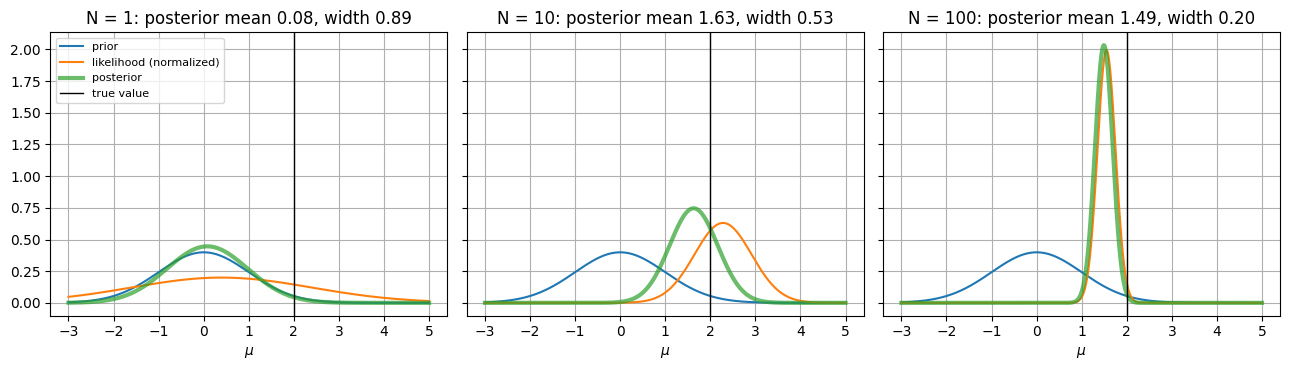

In [4]:
mu_0, tau_0 = 0.0, 1.0            # prior: mu ~ N(0, 1)
mu_star, sigma = 2.0, 2.0         # true value and measurement uncertainty

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
mu = np.linspace(-3, 5, 600)
for ax, N in zip(axs, [1, 10, 100]):
    y = rng.normal(mu_star, sigma, size=N)
    ybar, sig_mean = np.mean(y), sigma / np.sqrt(N)
    tau_1 = (1/tau_0**2 + 1/sig_mean**2)**-0.5
    mu_1 = tau_1**2 * (mu_0/tau_0**2 + ybar/sig_mean**2)
    ax.plot(mu, stats.norm.pdf(mu, mu_0, tau_0), label="prior")
    ax.plot(mu, stats.norm.pdf(mu, ybar, sig_mean), label="likelihood (normalized)")
    ax.plot(mu, stats.norm.pdf(mu, mu_1, tau_1), lw=3, alpha=0.7, label="posterior")
    ax.axvline(mu_star, color="k", lw=1, label="true value")
    ax.set_title(f"N = {N}: posterior mean {mu_1:.2f}, width {tau_1:.2f}"); ax.set_xlabel(r"$\mu$")
axs[0].legend(fontsize=8); plt.tight_layout()

### Poisson likelihood, Gamma prior

For count data $y_i \sim \mathrm{Poisson}(\theta)$, $i=1,\dots,N$, the likelihood is $p(y\,|\,\theta) \propto \theta^{\sum_i y_i} e^{-N\theta}$. The conjugate prior is the **Gamma distribution**,

$$
p(\theta) = \mathrm{Gamma}(\theta\,|\,\alpha, \beta) = \frac{\beta^\alpha}{\Gamma(\alpha)}\,\theta^{\alpha-1}e^{-\beta\theta} , \qquad \theta > 0 ,
$$

with hyperparameters $\alpha$ ("shape") and $\beta$ ("rate"), mean $\alpha/\beta$ and variance $\alpha/\beta^2$.

```{admonition} Two conventions for the Gamma distribution
:class: warning
We follow Gelman et al. and write $\mathrm{Gamma}(\alpha,\beta)$ with a *rate* $\beta$ (mean $\alpha/\beta$). Many other books, and `scipy`, use a *scale* parameter $\vartheta = 1/\beta$ instead, so that the mean is $\alpha\vartheta$. Check which one a formula uses before plugging in numbers. In `scipy`: `stats.gamma(a=alpha, scale=1/beta)`.
```

Multiplying the two,

$$
p(\theta\,|\,y) \propto \theta^{\alpha + \sum_i y_i - 1}\,e^{-(\beta + N)\theta} \quad\Longrightarrow\quad \theta\,|\,y \sim \mathrm{Gamma}\!\left(\alpha + \textstyle\sum_i y_i,\; \beta + N\right) .
$$ (eq:poisson-gamma)

Again the interpretation is that the prior is equivalent to previous data: $\alpha$ plays the role of "prior counts" and $\beta$ of "prior exposure". (If the exposure differs per data point, $y_i \sim \mathrm{Poisson}(t_i\theta)$, then $N$ is replaced by $\sum_i t_i$; you will use this in the exercises.)

### Example: kidney cancer death rates

The example from the lecture and from Gelman et al. (Section 2.7). For each of the roughly 3000 counties of the US we know the number of kidney-cancer deaths $y_j$ over 10 years and the population $n_j$. The map of the counties with the highest raw death rates $y_j/(10 n_j)$ is dominated by *small, rural* counties. So is the map of the counties with the *lowest* rates. The reason is not epidemiology but Poisson noise: in a county of 1000 people, 0 or 1 death in a decade makes the raw rate either zero or twice the national average.

The Bayesian solution: model $y_j \sim \mathrm{Poisson}(10\,n_j\,\theta_j)$ and put a prior on the county rates $\theta_j$ that describes the *distribution of rates across the country*. Matching the mean and variance of the observed distribution of rates gives a Gamma prior with $\alpha \approx 20$ and $\beta \approx 430\,000$ (in units of deaths per person-year), i.e. a mean rate of $4.7\times10^{-5}$ per year. With Eq. {eq}`eq:poisson-gamma` the posterior for each county is $\mathrm{Gamma}(20 + y_j,\; 430\,000 + 10n_j)$, with posterior mean

$$
E[\theta_j\,|\,y_j] = \frac{20 + y_j}{430\,000 + 10 n_j} .
$$

For a small county ($10n_j \ll 430\,000$) the posterior mean is close to the prior mean $20/430\,000$, whatever $y_j$ is: the data carry little information and the estimate *shrinks* towards the national average. For a large county ($10n_j \gg 430\,000$) the posterior mean is essentially the raw rate $y_j/10n_j$. The prior automatically applies a population-dependent weighting, which is exactly what common sense asked for. Let's simulate this.

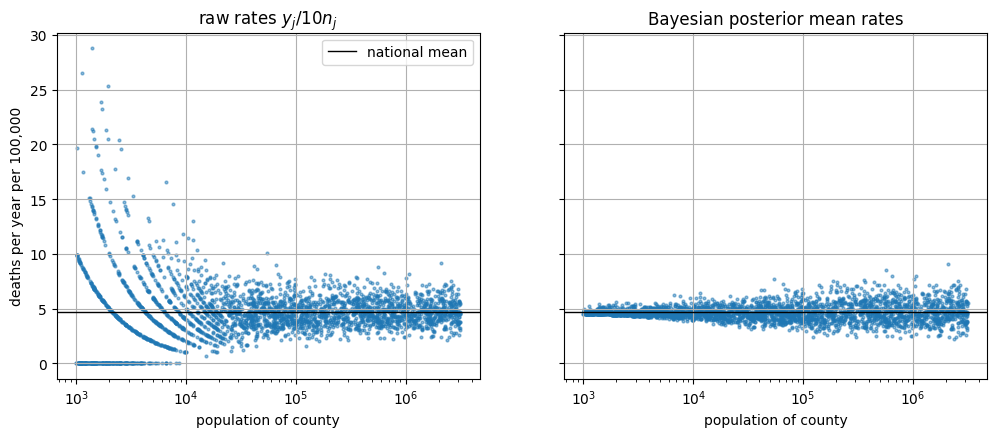

In [5]:
alpha, beta = 20, 430_000
n_counties = 3000
n_pop = 10**rng.uniform(3, 6.5, size=n_counties)                 # populations from 1e3 to 3e6
theta_true = rng.gamma(alpha, 1/beta, size=n_counties)            # true rates, drawn from the prior
y_deaths = rng.poisson(10 * n_pop * theta_true)                   # deaths in 10 years

rate_raw = y_deaths / (10 * n_pop)
rate_post = (alpha + y_deaths) / (beta + 10 * n_pop)              # posterior mean

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, rate, title in zip(axs, [rate_raw, rate_post], ["raw rates $y_j / 10 n_j$", "Bayesian posterior mean rates"]):
    ax.scatter(n_pop, rate * 1e5, s=4, alpha=0.5)
    ax.axhline(alpha / beta * 1e5, color="k", lw=1, label="national mean")
    ax.set_xscale("log"); ax.set_xlabel("population of county"); ax.set_title(title)
axs[0].set_ylabel("deaths per year per 100,000"); axs[0].legend();

The raw rates of the small counties scatter wildly (many are exactly zero); the posterior means are pulled towards the national average with a strength that decreases with population. This *shrinkage* is one of the most useful things Bayesian inference does, and it appears whenever many noisy measurements of similar quantities are combined (it is the starting point of *hierarchical models*, beyond this course).

```{admonition} Are we using the data twice?
:class: note
The prior here was constructed from the very same data (the distribution of all county rates) that we then analyse county by county. Strictly this is not allowed, and the procedure is a shortcut, known as *empirical Bayes*, for a hierarchical model in which the hyperparameters $\alpha,\beta$ are themselves inferred from the data. For 3000 counties the difference is negligible; for 3 counties it would not be.
```

## 5.6 Priors in practice

**Physical constraints as priors.** "The mass cannot be negative", "$\epsilon \geq 0$", "the fraction lies in $[0,1]$": implement as $p(\theta) = 0$ outside the allowed range and constant inside. If the data already prefer the allowed region, the posterior barely changes (perhaps a slightly narrower interval, because the excluded tail is gone). If the data push against the boundary, the prior matters a lot, and the result is typically an *upper limit*.

**Results from other experiments as priors.** The right way to combine a previous measurement with your own data is to use *their posterior as your prior*. For this you need their full posterior (or enough information to reconstruct their likelihood: the data, the exposure, the background rate), not just a summary. An "upper limit at 95% CL" quoted by another group compresses their posterior into a single number and cannot be used quantitatively; nor can a point estimate without a distribution. Also keep in mind which prior *they* used to obtain their posterior.

**Does the prior matter?** Check it. Rerun the analysis with a different but reasonable prior (flat versus flat-in-log, broader Gaussian); if the posterior changes noticeably, your data are not constraining that parameter and your report should say so. If it does not change, no one can accuse you of subjectivity. With abundant data the likelihood dominates and the prior is irrelevant; the prior is important precisely in the regime where the data are weak, which is also the regime where an honest statement of your assumptions is most needed.

## 5.7 Test yourself

````{admonition} Q1. Combining experiments (exam 2023)
:class: tip
Your experiment (2 counts in 10 s, flat prior) gives a posterior for a dark-matter decay rate $\theta$ that peaks at $0.2$ s$^{-1}$. Another group reports $\theta < 0.3$ s$^{-1}$ at 95% CL.

1. Explain in one sentence how you could use the other experiment in your inference of $\theta$.
2. Do you expect your inference to change? Sketch the new posterior.
3. Does the upper limit contain enough information to use the other result quantitatively? If not, what else do you need?

```{admonition} Answer
:class: dropdown
1. Use it as the prior on $\theta$ instead of a flat prior.
2. Yes: the upper limit of 0.3 is close to the peak of our posterior, so a prior that falls off above 0.3 will cut the high-rate tail and the posterior will drop faster above $\approx 0.3$; the peak moves slightly down.
3. No. The upper limit compresses their posterior into a single number. We need their full posterior distribution (and the prior they used), or the ingredients of their likelihood: number of counts, exposure time and background rate.
```
````

````{admonition} Q2. A physical bound on the slope (practice exam)
:class: tip
You fit $y = a + bx$ and are told that a negative slope, $b < 0$, is impossible based on the laws of physics. How do you include this in your inference of $\theta = (a,b)$, and do you expect your estimate of $b$ to change?

```{admonition} Answer
:class: dropdown
Via the prior: $p(b) = 0$ for $b<0$ and constant otherwise (and flat in $a$). If the data already prefer $b>0$ the estimate changes little (at most a slightly narrower credible interval than least squares, which allows negative slopes). If the data are consistent with $b \approx 0$, the posterior will pile up at the boundary and the result becomes an upper limit on $b$.
```
````

````{admonition} Q3. How much is a prior worth?
:class: tip
You measure a quantity $\mu$ with $N$ measurements of uncertainty $\sigma = 2$ each. A colleague's earlier experiment gives the prior $\mu \sim \mathcal{N}(\mu_0, \tau_0^2)$ with $\tau_0 = 0.5$. How many of your own measurements is this prior "worth", and for which $N$ does your posterior width become smaller than the prior width?

```{admonition} Answer
:class: dropdown
From Eq. {eq}`eq:gauss-gauss` the posterior precision is $1/\tau_0^2 + N/\sigma^2$. The prior contributes as much as $N_{\rm eff} = \sigma^2/\tau_0^2 = 4/0.25 = 16$ of your measurements. The posterior width $\tau_1 = (1/\tau_0^2 + N/\sigma^2)^{-1/2}$ is always smaller than $\tau_0$, already for $N=1$; it becomes smaller than the width you would get from your data alone, $\sigma/\sqrt N$, for every $N$ as well. The prior stops mattering (contributes less than half the precision) once $N > 16$.
```
````

## Sources and further reading

* Gelman et al. (2013), *Bayesian Data Analysis* (3rd ed.), [free PDF](https://sites.stat.columbia.edu/gelman/book/BDA3.pdf), Sections 2.4–2.7 (conjugate priors, the kidney-cancer example) and Sections 2.8–2.9 (non-informative and weakly informative priors); Table A.1 lists the common distributions with their parametrizations.
* Hogg, Bovy & Lang (2010), [arXiv:1008.4686](https://arxiv.org/abs/1008.4686), Section 3 and the notes, on why priors are needed for marginalization and on flat-in-log priors for scale parameters.
* Gelman (2006), *Prior distributions for variance parameters in hierarchical models*, Bayesian Analysis 1, 515, [doi:10.1214/06-BA117A](https://doi.org/10.1214/06-BA117A).
* The Stan development team, [*Prior choice recommendations*](https://github.com/stan-dev/stan/wiki/Prior-Choice-Recommendations), a practical wiki on weakly informative priors (this Stan is the probabilistic-programming language, named after Stanislaw Ulam).